In [22]:
import sys
print(sys.executable)


c:\Users\User\mlops-retail-project\.venv\Scripts\python.exe


In [23]:
import pandas as pd

df = pd.read_excel("../data/raw/online_retail.xlsx")

df.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom


In [24]:
df.shape

(541909, 8)

In [25]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 541909 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype         
---  ------       --------------   -----         
 0   InvoiceNo    541909 non-null  object        
 1   StockCode    541909 non-null  object        
 2   Description  540455 non-null  object        
 3   Quantity     541909 non-null  int64         
 4   InvoiceDate  541909 non-null  datetime64[us]
 5   UnitPrice    541909 non-null  float64       
 6   CustomerID   406829 non-null  float64       
 7   Country      541909 non-null  str           
dtypes: datetime64[us](1), float64(2), int64(1), object(3), str(1)
memory usage: 33.1+ MB


In [26]:
df.describe()

,Quantity,InvoiceDate,UnitPrice,CustomerID
count,541909.000000,541909,541909.000000,406829.000000
mean,9.552250,2011-07-04 13:34:57.156386,4.611114,15287.690570
min,-80995.000000,2010-12-01 08:26:00,-11062.060000,12346.000000
25%,1.000000,2011-03-28 11:34:00,1.250000,13953.000000
50%,3.000000,2011-07-19 17:17:00,2.080000,15152.000000
75%,10.000000,2011-10-19 11:27:00,4.130000,16791.000000
max,80995.000000,2011-12-09 12:50:00,38970.000000,18287.000000
std,218.081158,NaN,96.759853,1713.600303


In [27]:
df.isnull().sum()

InvoiceNo           0
StockCode           0
Description      1454
Quantity            0
InvoiceDate         0
UnitPrice           0
CustomerID     135080
Country             0
dtype: int64

*LIMPIEZA DE DATOS*

Se eliminaron registros sin CustomerID debido a que no permiten realizar análisis de comportamiento de clientes, lo cual es fundamental para entender patrones de compra y valor del cliente.

In [28]:
df = df.dropna(subset=['CustomerID'])

In [29]:
df = df[~df['InvoiceNo'].astype(str).str.startswith('C')]


In [30]:
df = df[df['Quantity'] > 0]
df = df[df['UnitPrice'] > 0] # ELIMICION VALORES NEGATIVOS

In [31]:
df.shape

(397884, 8)

Después del proceso de limpieza, el dataset se redujo de 541,909 a 397,884 registros, eliminando datos incompletos, devoluciones y valores inconsistentes

*FEATURE ENGINEERING*

In [32]:
df['TotalPrice'] = df['Quantity'] * df['UnitPrice']

In [33]:
df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'])

In [34]:
df['Year'] = df['InvoiceDate'].dt.year
df['Month'] = df['InvoiceDate'].dt.month
df['Day'] = df['InvoiceDate'].dt.day #VARIABLES DE TIEMPO

In [35]:
df.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,TotalPrice,Year,Month,Day
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom,15.30,2010,12,1
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34,2010,12,1
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom,22.00,2010,12,1
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34,2010,12,1
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34,2010,12,1


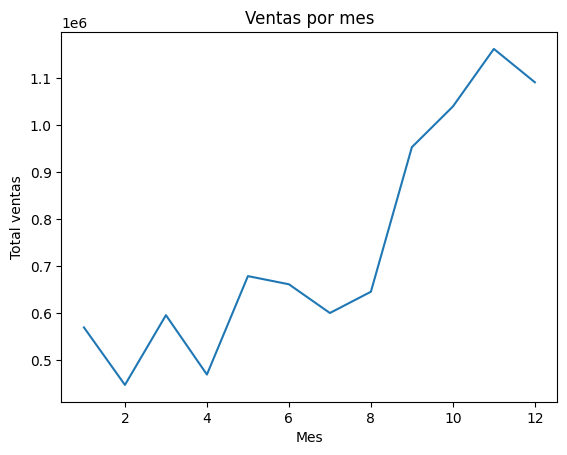

In [36]:
import seaborn as sns
import matplotlib.pyplot as plt

monthly_sales = df.groupby('Month')['TotalPrice'].sum()

sns.lineplot(x=monthly_sales.index, y=monthly_sales.values)
plt.title("Ventas por mes")
plt.xlabel("Mes")
plt.ylabel("Total ventas")
plt.show()

 Ventas por mes

Se observa un aumento significativo en las ventas a partir del mes 8, alcanzando su punto máximo en los meses 10 y 11. Esto sugiere un comportamiento estacional, posiblemente relacionado con eventos comerciales o temporadas festivas como fin de año, ademas de ofertas como black friday,

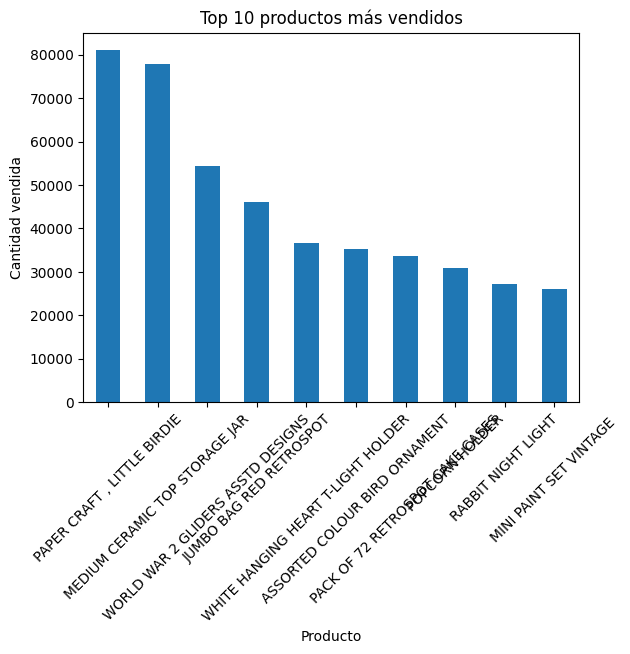

In [37]:
top_products = df.groupby('Description')['Quantity'].sum().sort_values(ascending=False).head(10)

top_products.plot(kind='bar')
plt.title("Top 10 productos más vendidos")
plt.xlabel("Producto")
plt.ylabel("Cantidad vendida")
plt.xticks(rotation=45)
plt.show()

Productos más vendidos

Se observa que un pequeño grupo de productos concentra la mayor cantidad de ventas. Esto indica una distribución desigual, donde ciertos productos tienen una alta demanda mientras que la mayoría tiene una participación menor.

Este comportamiento sugiere una posible distribución tipo Pareto, donde el 20% de los productos generan la mayor parte de las ventas.

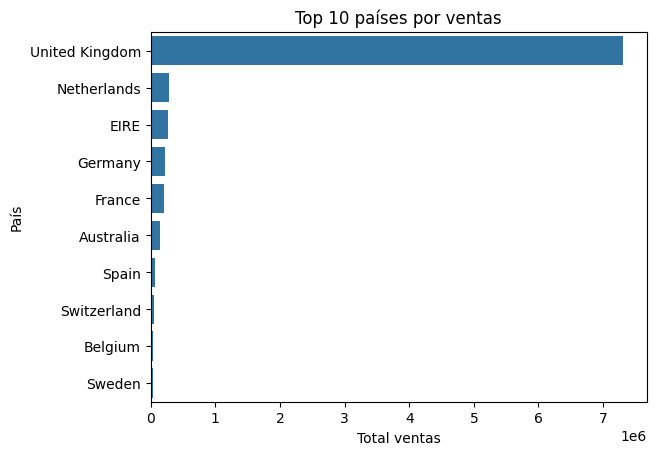

In [38]:
country_sales = df.groupby('Country')['TotalPrice'].sum().sort_values(ascending=False).head(10)

sns.barplot(x=country_sales.values, y=country_sales.index)
plt.title("Top 10 países por ventas")
plt.xlabel("Total ventas")
plt.ylabel("País")
plt.show()

Ventas por país

Se observa que el Reino Unido concentra la gran mayoría de las ventas, superando ampliamente a los demás países. Esto indica una fuerte dependencia del mercado principal.

Los otros países presentan una participación significativamente menor, lo que sugiere oportunidades de expansión internacional o una concentración geográfica del negocio.

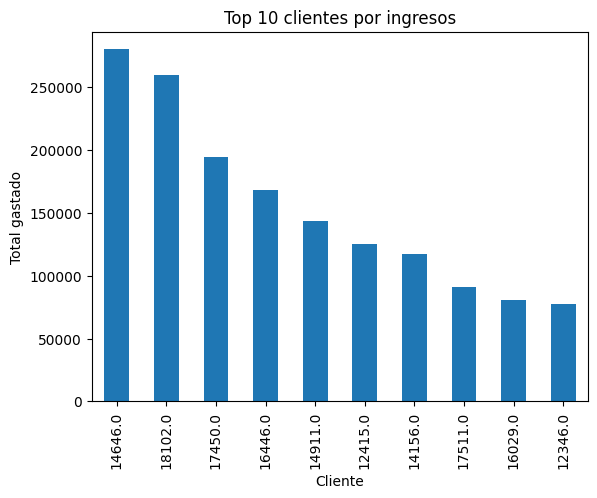

In [39]:
top_customers = df.groupby('CustomerID')['TotalPrice'].sum().sort_values(ascending=False).head(10)

top_customers.plot(kind='bar')
plt.title("Top 10 clientes por ingresos")
plt.xlabel("Cliente")
plt.ylabel("Total gastado")
plt.show()

Clientes más valiosos

Se observa que un pequeño grupo de clientes genera una gran proporción de los ingresos totales. Esto sugiere una distribución desigual del valor de los clientes, donde unos pocos clientes son altamente valiosos.

Este comportamiento es consistente con el principio de Pareto (80/20), donde un porcentaje reducido de clientes contribuye significativamente a los ingresos.

Clientes VIP 💎
Segmentación futura
Base para modelos como:
RFM
Customer Lifetime Value

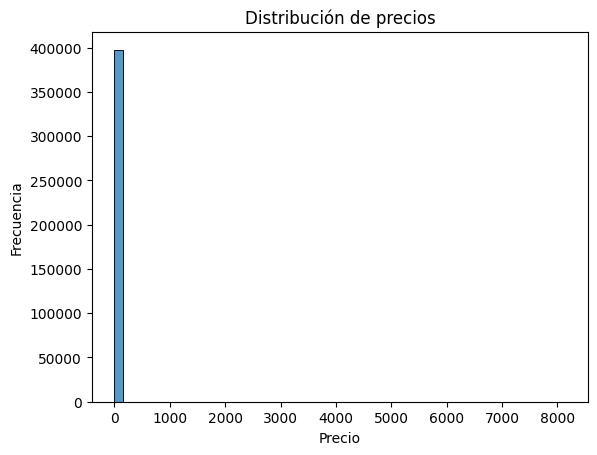

In [40]:
sns.histplot(df['UnitPrice'], bins=50)
plt.title("Distribución de precios")
plt.xlabel("Precio")
plt.ylabel("Frecuencia")
plt.show()

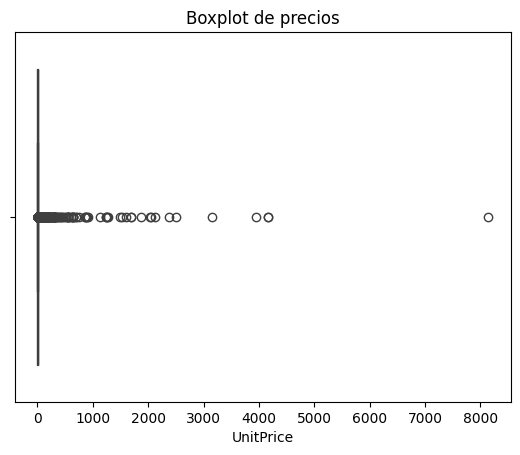

In [41]:
sns.boxplot(x=df['UnitPrice'])
plt.title("Boxplot de precios")
plt.show()

Distribución de precios y outliers

El boxplot muestra que la mayoría de los precios se concentran en valores bajos, mientras que existen numerosos valores atípicos (outliers) que alcanzan precios significativamente altos.

Esto confirma que la distribución de precios está altamente sesgada hacia la derecha, lo que puede afectar análisis estadísticos y modelos si no se trata adecuadamente.
Además, la presencia de múltiples outliers sugiere la existencia de productos premium o registros atípicos que podrían requerir tratamiento especial en etapas posteriores del análisis o modelado.

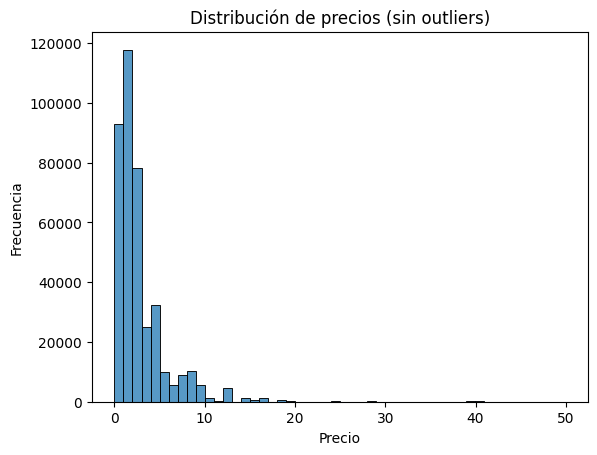

In [42]:
sns.histplot(df[df['UnitPrice'] < 50]['UnitPrice'], bins=50)
plt.title("Distribución de precios (sin outliers)")
plt.xlabel("Precio")
plt.ylabel("Frecuencia")
plt.show()

Al eliminar los valores atípicos, se observa claramente que la mayoría de los productos se concentran en rangos de precios bajos, principalmente entre 0 y 10 unidades monetarias.

La distribución presenta una forma asimétrica positiva (sesgada a la derecha), donde a medida que aumenta el precio, la frecuencia disminuye significativamente.

Esto sugiere que el negocio está enfocado en productos de bajo costo con alta rotación.